<a href="https://colab.research.google.com/github/Tor4narek/AudioClassification/blob/main/sounds.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/dogs/images/Images"

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU: []


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Классы:", class_names)
print("Количество классов:", num_classes)

Found 20641 files belonging to 120 classes.
Using 16513 files for training.
Found 20641 files belonging to 120 classes.
Using 4128 files for validation.
Классы: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n0209

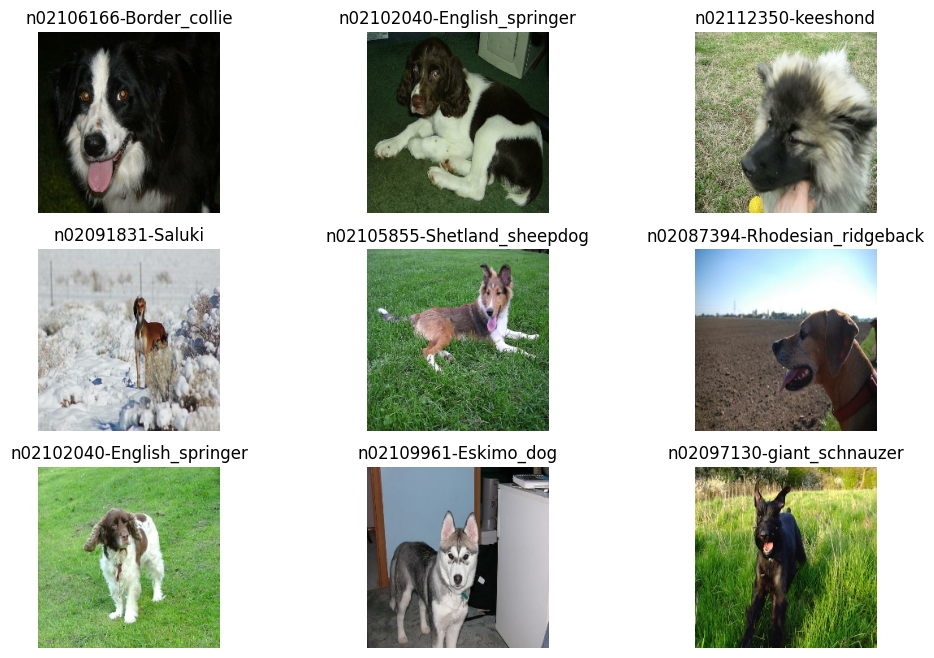

In [ ]:
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [ ]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │       153,720 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,203,291 (16.03 MB)

 Trainable params: 4,161,268 (15.87 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
initial_epochs = 5

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs
)


Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 4267s 8s/step - accuracy: 0.4737 - loss: 1.9596 - val_accuracy: 0.5552 - val_loss: 1.5307
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 209s 403ms/step - accuracy: 0.6469 - loss: 1.1814 - val_accuracy: 0.6335 - val_loss: 1.2669
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 215s 416ms/step - accuracy: 0.7066 - loss: 0.9545 - val_accuracy: 0.6357 - val_loss: 1.3335
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 215s 416ms/step - accuracy: 0.7464 - loss: 0.8057 - val_accuracy: 0.5860 - val_loss: 1.6001
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 215s 416ms/step - accuracy: 0.7810 - loss: 0.6906 - val_accuracy: 0.6194 - val_loss: 1.4934


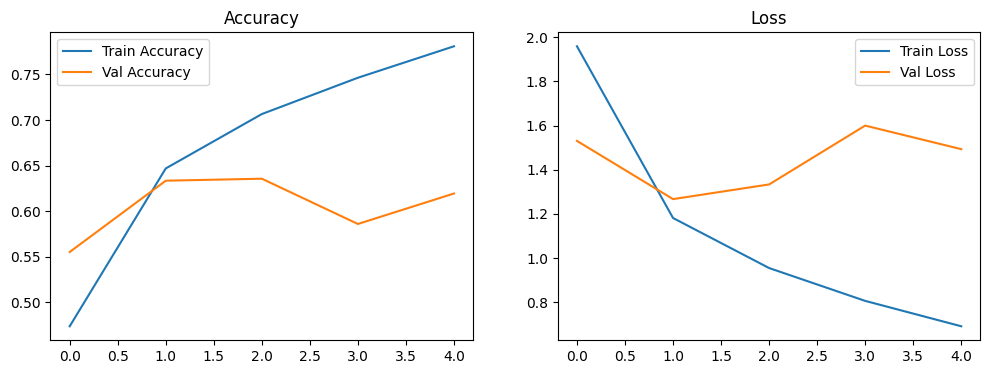

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
base_model.trainable = True

# Замораживаем нижнюю часть, обучаем только верхние слои
fine_tune_at = 200

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
fine_tune_epochs = 5
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1] + 1
)

Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 124s 210ms/step - accuracy: 0.8231 - loss: 0.5596 - val_accuracy: 0.6860 - val_loss: 1.1559
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 139s 204ms/step - accuracy: 0.8413 - loss: 0.4997 - val_accuracy: 0.6955 - val_loss: 1.1099
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 206ms/step - accuracy: 0.8539 - loss: 0.4666 - val_accuracy: 0.7030 - val_loss: 1.0821
Epoch 9/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 141s 204ms/step - accuracy: 0.8616 - loss: 0.4371 - val_accuracy: 0.7045 - val_loss: 1.0642
Epoch 10/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 106s 204ms/step - accuracy: 0.8668 - loss: 0.4220 - val_accuracy: 0.7054 - val_loss: 1.0489


In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation loss: {loss:.4f}")
print(f"Validation accuracy: {accuracy:.4f}")

129/129 ━━━━━━━━━━━━━━━━━━━━ 19s 149ms/step - accuracy: 0.7054 - loss: 1.0489
Validation loss: 1.0489
Validation accuracy: 0.7054


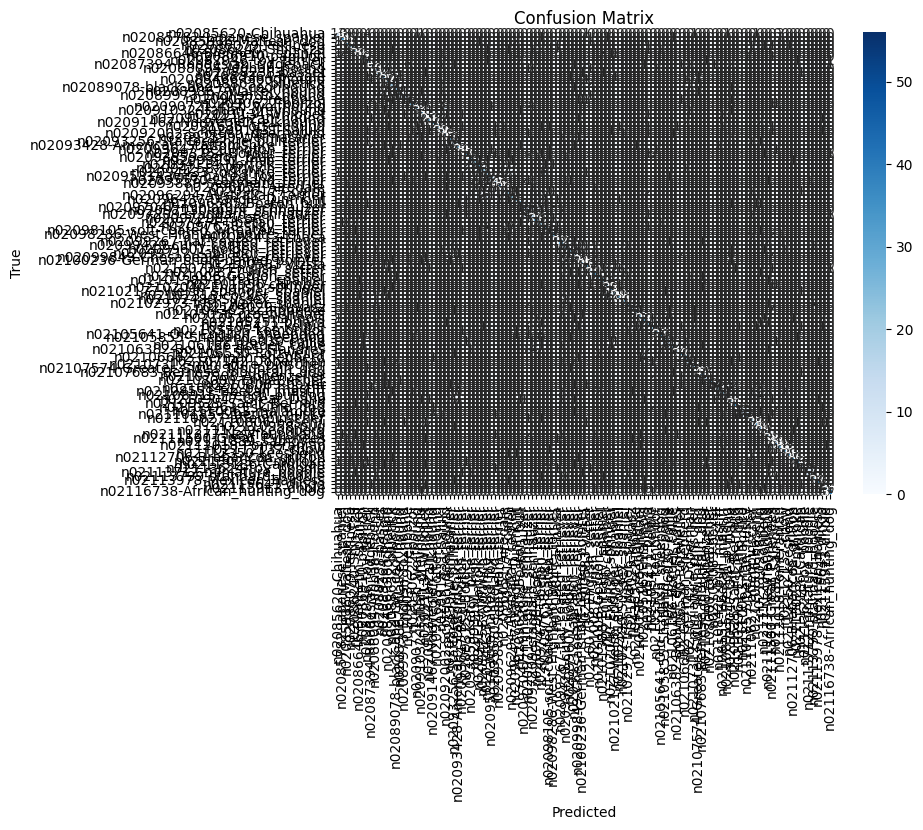

                                          precision    recall  f1-score   support

                     n02085620-Chihuahua       0.54      0.50      0.52        26
              n02085782-Japanese_spaniel       0.90      0.81      0.85        43
                   n02085936-Maltese_dog       0.76      0.71      0.73        48
                      n02086079-Pekinese       0.81      0.70      0.75        30
                      n02086240-Shih-Tzu       0.51      0.58      0.54        45
              n02086646-Blenheim_spaniel       0.94      0.77      0.85        39
                      n02086910-papillon       0.86      0.95      0.90        38
                   n02087046-toy_terrier       0.54      0.76      0.63        25
           n02087394-Rhodesian_ridgeback       0.60      0.46      0.52        39
                  n02088094-Afghan_hound       0.82      0.93      0.88        60
                        n02088238-basset       0.88      0.55      0.68        40
               

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

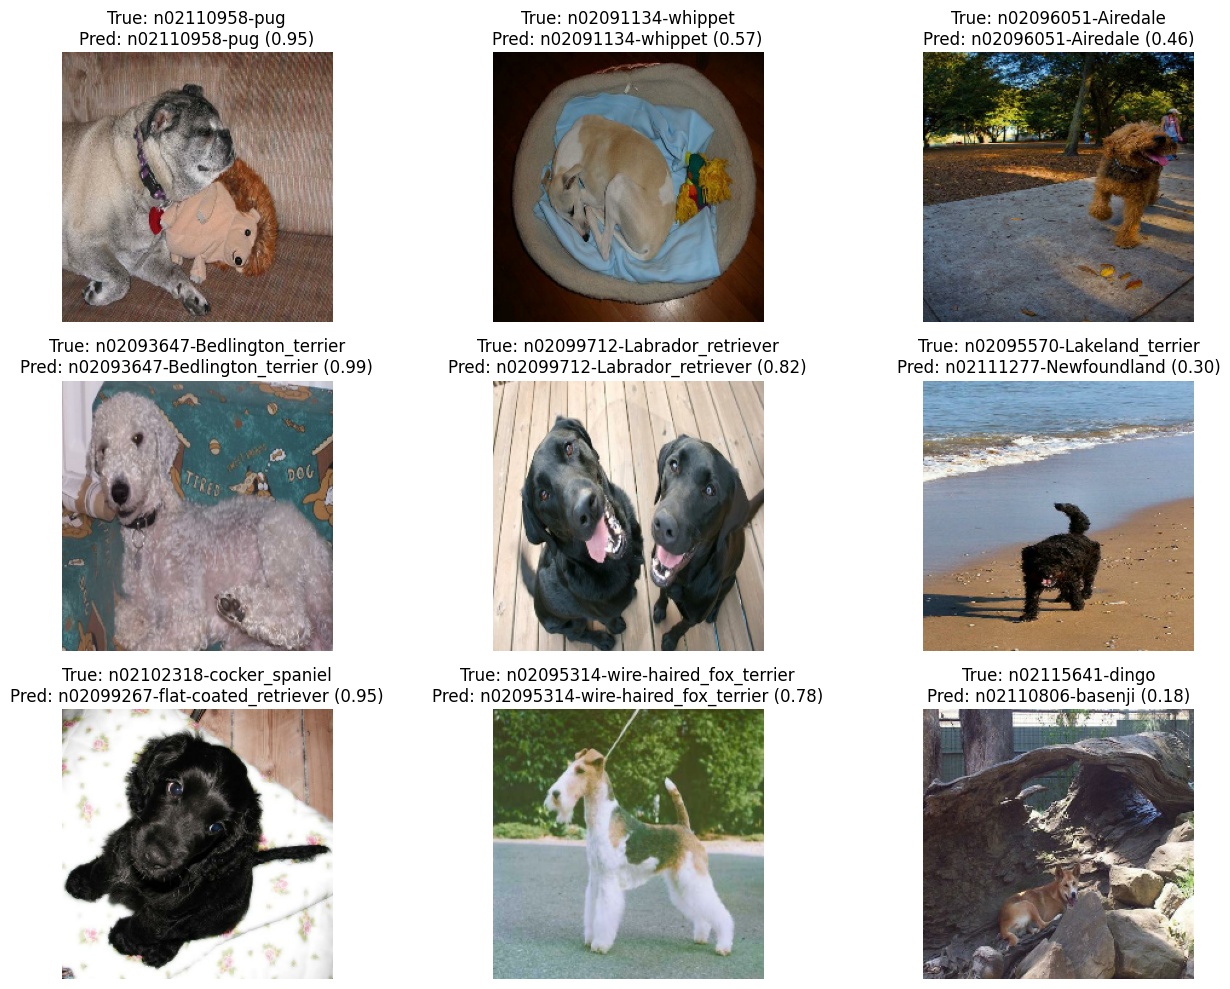

In [ ]:
plt.figure(figsize=(14, 10))

for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_classes[i]]
        conf = np.max(preds[i])
        plt.title(f"True: {true_label}\nPred: {pred_label} ({conf:.2f})")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
img_file = "/content/drive/MyDrive/dogs/Japanese_Shiba_Inu1.jpg"

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array

IMG_SIZE = (224, 224)

img = load_img(img_file, target_size=IMG_SIZE)
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # (1, 224, 224, 3)

In [ ]:
preds = model.predict(img_array, verbose=0)
pred_class = np.argmax(preds[0])
conf = np.max(preds[0])

pred_label = class_names[pred_class]

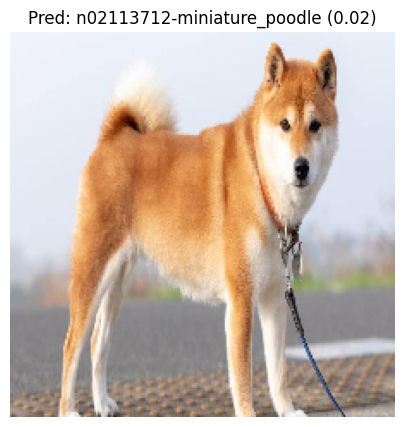

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Pred: {pred_label} ({conf:.2f})")
plt.axis("off")
plt.show()

In [ ]:
import json

model.save("/content/drive/MyDrive/ai/dog_breed_model.keras")

with open("/content/drive/MyDrive/ai/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Модель сохранена")

Модель сохранена
